# Personal Finance Assistant — Demo

This notebook shows how to use the package and what its outputs look like,
using the example data in `examples/sample_transactions.csv`
(about ten months of anonymised transactions).

The notebook only **reads** the example file. It does not change your own
account file.

## Running the command-line program

Install the package once, then start the interactive menu:

```bash
uv pip install -e .
uv run -m personal-finance-assistant
```

Inside the program, type `help` to see all commands. A typical first session:

```text
pfa> import
  path to CSV file: examples/sample_transactions.csv
pfa> balance
pfa> predict
pfa> chart
pfa> exit
```

The rest of this notebook uses the same functions directly from Python.

### Changing settings in the program

Type `settings` to see all settings and their current values:

```text
pfa> settings
Current settings:
  income_categories: salary, scholarship, gift, other
  expense_categories: rent, groceries, transport, insurance, subscriptions, leisure, health, education, savings, other
  monthly_expense_limit: 0.0
  report_months: 3
  recurring_min_interval_days: 25
  recurring_max_interval_days: 35
  recurring_amount_tolerance: 0.15
  low_savings_rate: 0.1
  high_spending_share: 0.3
  forecast_months: 3
  forecast_method: trend
  emergency_fund_months: 3
Change settings:
    add-cat
    remove-cat
    set
    back
```

Then choose an action. Some examples:

```text
pfa-settings> set
  setting name: forecast_months
  new value: 6
pfa-settings> set
  setting name: forecast_method
  new value: recurring
pfa-settings> set
  setting name: recurring_amount_tolerance
  new value: 0.2
pfa-settings> add-cat
  income or expense? expense
  new category name: travel
pfa-settings> remove-cat
  income or expense? expense
  category to remove: travel
pfa-settings> back
```

- `forecast_months: 6` forecasts six months ahead instead of three.
- `forecast_method: recurring` uses the recurring-payments forecast instead
  of the trend line.
- `recurring_amount_tolerance: 0.2` lets the amount of a recurring payment
  vary by up to 20% from month to month.
- The category `other` is required and cannot be removed.

Every change is saved immediately, so it is still there the next time
you start the program. The README has a short description of every setting.

## Importing the package

The main functions are exposed in the top-level package, so they can be
imported directly from `personal_finance_assistant`.

In [1]:
import pandas as pd
from IPython.display import Image

import personal_finance_assistant as pfa
from personal_finance_assistant import (
    average_monthly_expense_by_category,
    find_recurring_transactions,
    generate_recommendations,
    monthly_income_and_expense,
    predict_balance_recurring,
    predict_balance_trend,
    read_csv,
    save_overview_chart,
)
from personal_finance_assistant.settings import DEFAULT_SETTINGS

print("Version:", pfa.__version__)

settings = dict(DEFAULT_SETTINGS)  # default settings, so the results are reproducible

Version: 2.0.0


## Loading the example data

`read_csv` returns the valid transactions and a list of rows that were skipped.

In [2]:
transactions, errors = read_csv("../examples/sample_transactions.csv")

print(f"{len(transactions)} transactions loaded, {len(errors)} rows skipped")
pd.DataFrame([tx.to_row() for tx in transactions]).head(10)

1418 transactions loaded, 0 rows skipped


,id,date,type,amount,category,note
0,230dd488,2025-12-01,income,1500.00,other,opening balance
1,5f6e7269,2025-12-01,income,1000.00,salary,monthly income
2,eb01cbc8,2025-12-01,expense,129.00,insurance,health insurance
3,eafd8bfe,2025-12-01,expense,0.85,groceries,groceries
4,9ddcac51,2025-12-01,expense,2.39,groceries,groceries
5,09f1bd2d,2025-12-01,expense,0.48,groceries,groceries
6,49ba6699,2025-12-01,expense,2.13,groceries,groceries
7,01a96631,2025-12-03,expense,2.22,health,personal care
8,77403690,2025-12-03,expense,3.55,health,personal care
9,ed0d8624,2025-12-03,expense,3.95,health,personal care


In [3]:
balance = sum(tx.signed_amount for tx in transactions)
print(f"Current balance: {balance:.2f}")

Current balance: 1059.76


## Income and expenses per month

In [4]:
monthly_income_and_expense(transactions)

type,income,expense
month,,
2025-12,2500.0,811.59
2026-01,1000.0,1026.20
2026-02,1000.0,1087.81
2026-03,1000.0,1002.36
2026-04,1000.0,1140.63
2026-05,1000.0,852.48
2026-06,1000.0,1254.42
2026-07,1000.0,941.26
2026-08,1000.0,1347.68


## Average monthly expense per category

In [5]:
average_monthly_expense_by_category(transactions)

category
rent             378.00
groceries        177.08
other            170.31
insurance        129.00
education         66.07
subscriptions     55.46
health            42.11
leisure           22.90
transport          3.10
Name: amount, dtype: float64

## Recurring payments

Groups of transactions (same type and category) that repeat roughly every
month with a similar amount.

In [6]:
pd.DataFrame(find_recurring_transactions(transactions, settings))

,type,category,average_amount,average_interval_days,occurrences
0,income,salary,1000.0,30.4,10
1,expense,insurance,129.0,30.4,10
2,expense,rent,420.0,29.6,9


## Forecast: two methods compared

- **trend** (default): linear regression on the daily balance. It includes all
  spending, also irregular costs like groceries.
- **recurring**: only recurring payments (salary, rent, insurance) are
  continued, so irregular spending is missing and the result is too optimistic.

In [7]:
forecast = pd.DataFrame({
    "months ahead": range(1, 7),
    "trend": [predict_balance_trend(m, transactions) for m in range(1, 7)],
    "recurring": [predict_balance_recurring(m, transactions, settings) for m in range(1, 7)],
})
forecast

,months ahead,trend,recurring
0,1,977.50,1510.76
1,2,895.24,1961.76
2,3,812.98,2412.76
3,4,730.72,2863.76
4,5,648.46,3314.76
5,6,566.20,3765.76


With this data the balance really went down by about 44 per month.
The trend method predicts a small decrease, which is close to that;
the recurring method predicts a large increase.

## Recommendations

In [8]:
for line in generate_recommendations(transactions, settings):
    print("-", line)

- You are saving only 0% of your income. Consider setting aside more each month.
- Spending on 'rent' (3780.00) is more than 30% of your income.


## Overview chart

The same image that the `chart` command creates. It is saved as
`examples/finance_overview.png` and is also shown in the README.

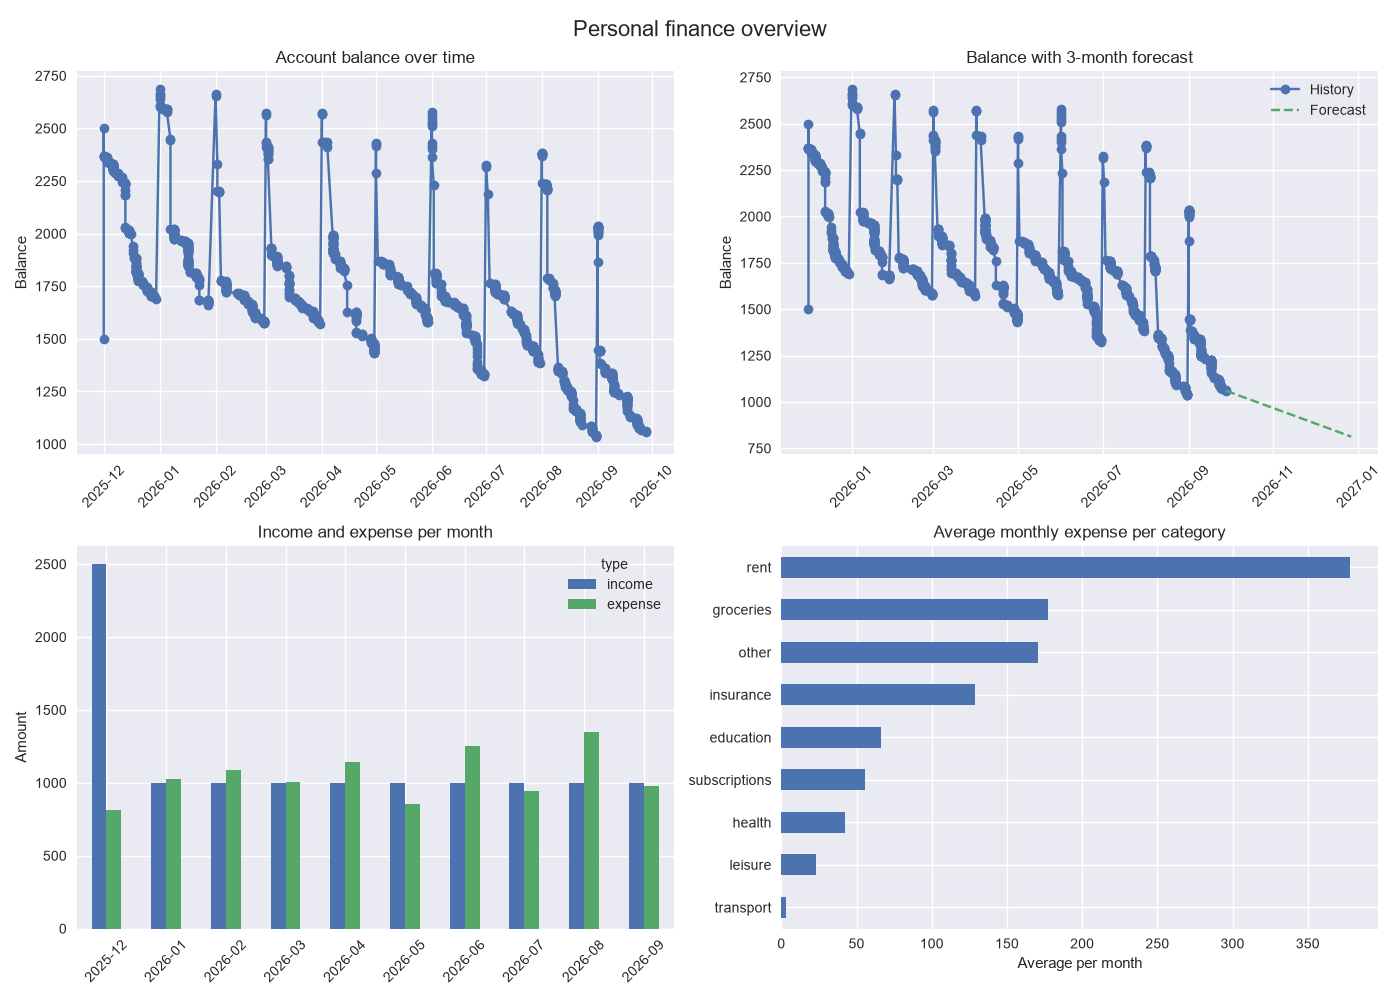

In [9]:
path = save_overview_chart(
    transactions=transactions,
    settings=settings,
    output_path="../examples/finance_overview.png",
)
Image(filename=str(path))